# 01 Data Setup and Recoding

## Research Question
Is the proportion of current cigarette use different between students who felt sad or hopeless and those who did not?

## Variables and Recoding Rules
* **Group Variable:** `SadOrHopeless` (1 = Exposed: code 1; 0 = Comparison: code 2)
* **Response Variable:** `CurrentCigaretteUse` (1 = Success: codes 2-7; 0 = Failure: code 1)

Missing values are removed prior to analysis.

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/YRBS_2007.csv')
df_clean = df[['SadOrHopeless', 'CurrentCigaretteUse']].dropna().copy()

print(f"Valid observations: {len(df_clean)}")

Valid observations: 13174


In [2]:
df_clean['Sad_recoded'] = df_clean['SadOrHopeless'].replace({1.0: 1, 2.0: 0})
df_clean['Smoke_recoded'] = df_clean['CurrentCigaretteUse'].replace({1.0: 0, 2.0: 1, 3.0: 1, 4.0: 1, 5.0: 1, 6.0: 1, 7.0: 1})

In [3]:
df_clean.to_csv('../data/processed/cleaned_Q8.csv', index=False, encoding='utf-8')

print("Data successfully saved to ../data/processed/cleaned_Q8.csv")

Data successfully saved to ../data/processed/cleaned_Q8.csv


# 02 Exploratory Data Analysis (EDA) and Group Summaries

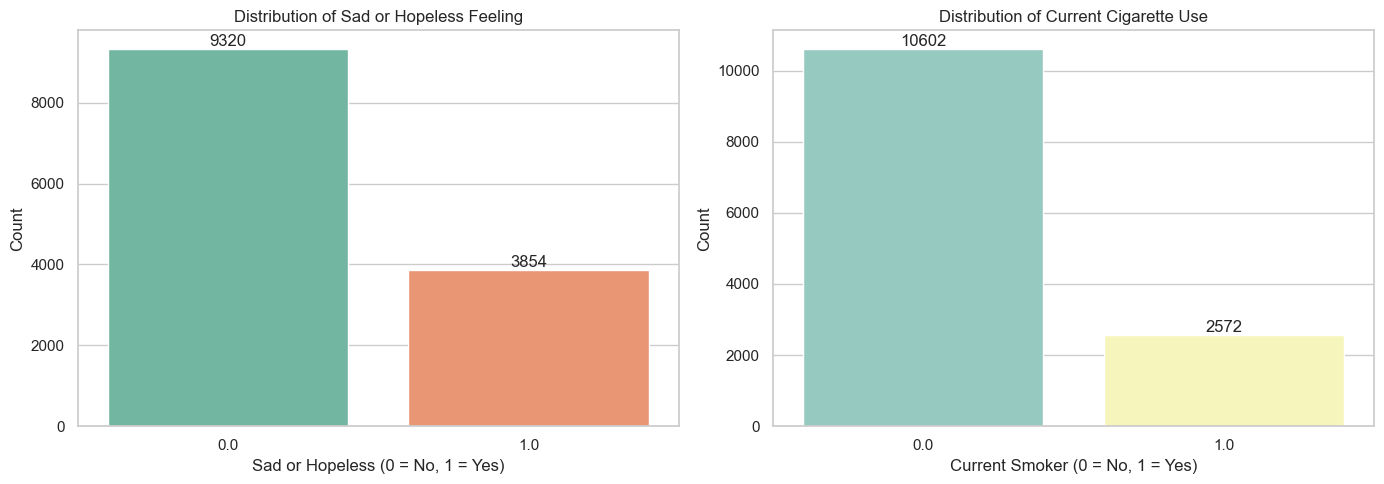

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Sad_recoded', data=df_clean, ax=axes[0], hue='Sad_recoded', palette="Set2", legend=False)
axes[0].set_title('Distribution of Sad or Hopeless Feeling')
axes[0].set_xlabel('Sad or Hopeless (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.countplot(x='Smoke_recoded', data=df_clean, ax=axes[1], hue='Smoke_recoded', palette="Set3", legend=False)
axes[1].set_title('Distribution of Current Cigarette Use')
axes[1].set_xlabel('Current Smoker (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.savefig('../outputs/figures/basic_distributions.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

**Interpretation of Basic Distributions:**
The count plots show that the majority of students in the dataset did not report feeling sad or hopeless. Similarly, the majority of the students are non-smokers. The sample sizes are highly imbalanced but large enough for robust statistical testing.

In [5]:
group_summary = df_clean.groupby('Sad_recoded')['Smoke_recoded'].agg(['count', 'mean']).reset_index()
group_summary.columns = ['Sad (1=Yes, 0=No)', 'Sample Size (n)', 'Proportion (p)']

group_summary.to_csv('../outputs/summary/group_summary.csv', index=False, encoding='utf-8')

display(group_summary)

,"Sad (1=Yes, 0=No)",Sample Size (n),Proportion (p)
0,0.0,9320,0.161803
1,1.0,3854,0.276077


**Interpretation of Group Summaries:**
The table provides the exact sample sizes and the proportion of current smokers for each group. Numerically, the proportion of smokers appears higher in the group that felt sad or hopeless.

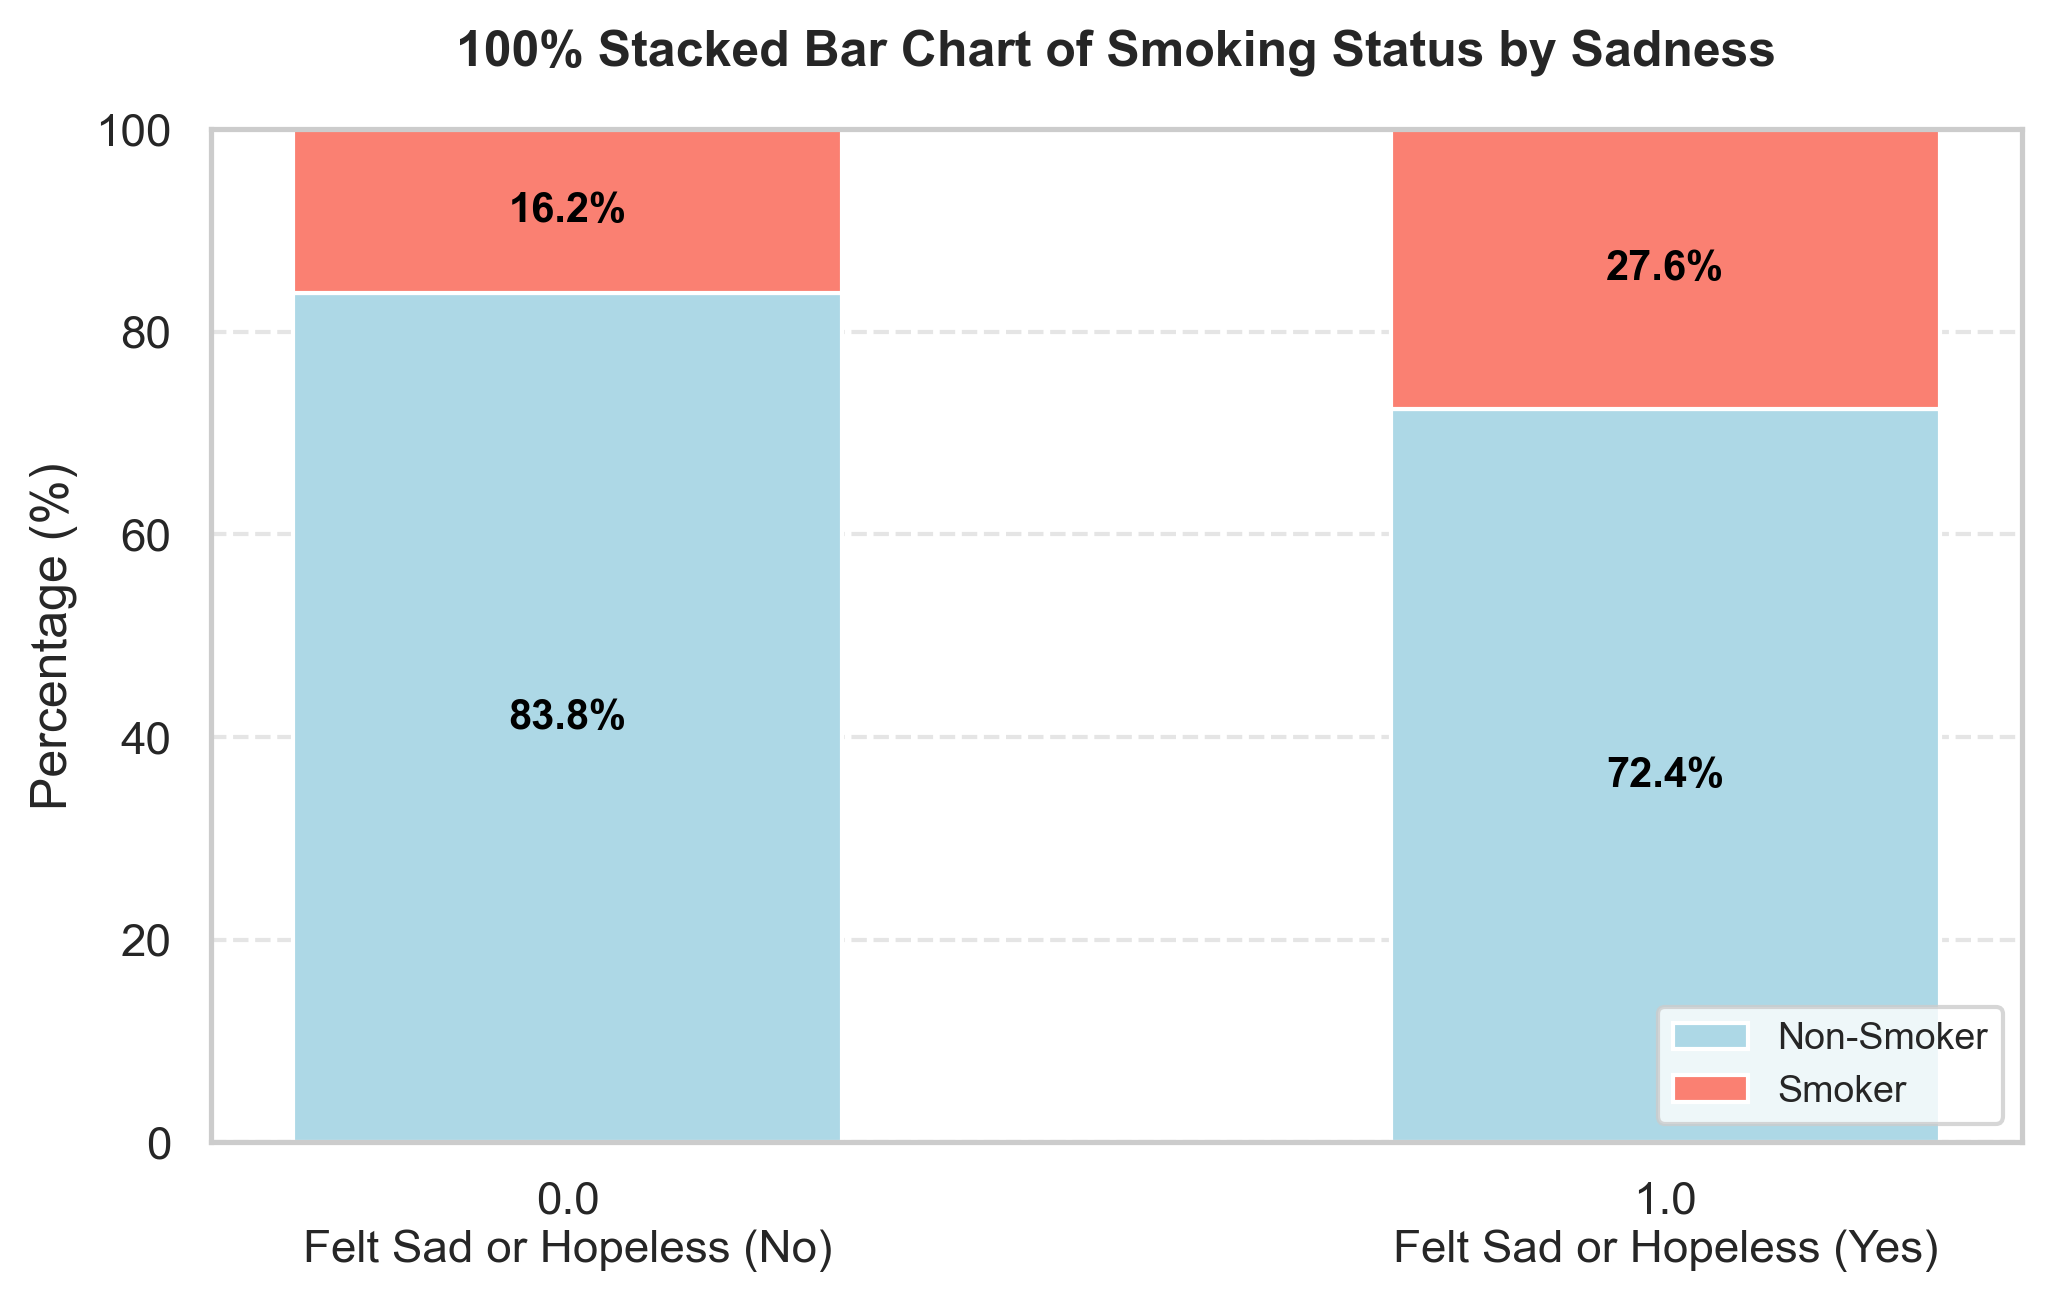

In [6]:
import matplotlib.pyplot as plt
import numpy as np

groups = ['0.0\nFelt Sad or Hopeless (No)', '1.0\nFelt Sad or Hopeless (Yes)']
non_smokers = [83.8197, 72.3923] 
smokers = [16.1803, 27.6077]     

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

bars_non = ax.bar(groups, non_smokers, label='Non-Smoker', color='lightblue', width=0.5, edgecolor='white')
bars_smoke = ax.bar(groups, smokers, bottom=non_smokers, label='Smoker', color='salmon', width=0.5, edgecolor='white')

for bar in bars_non:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:.1f}%', 
            ha='center', va='center', color='black', fontsize=10, fontweight='bold')

for bar in bars_smoke:
    y_base = bar.get_y()
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y_base + height/2, f'{height:.1f}%', 
            ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(loc='lower right', fontsize=9, markerscale=0.7, frameon=True)
ax.set_title('100% Stacked Bar Chart of Smoking Status by Sadness', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/stacked_bar_perfect.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation of Stacked Bar Chart:**
The 100% stacked bar chart illustrates the internal composition of each group. The salmon-colored segment (smokers) takes up a noticeably larger percentage of the total within the exposed group (Sad = 1).

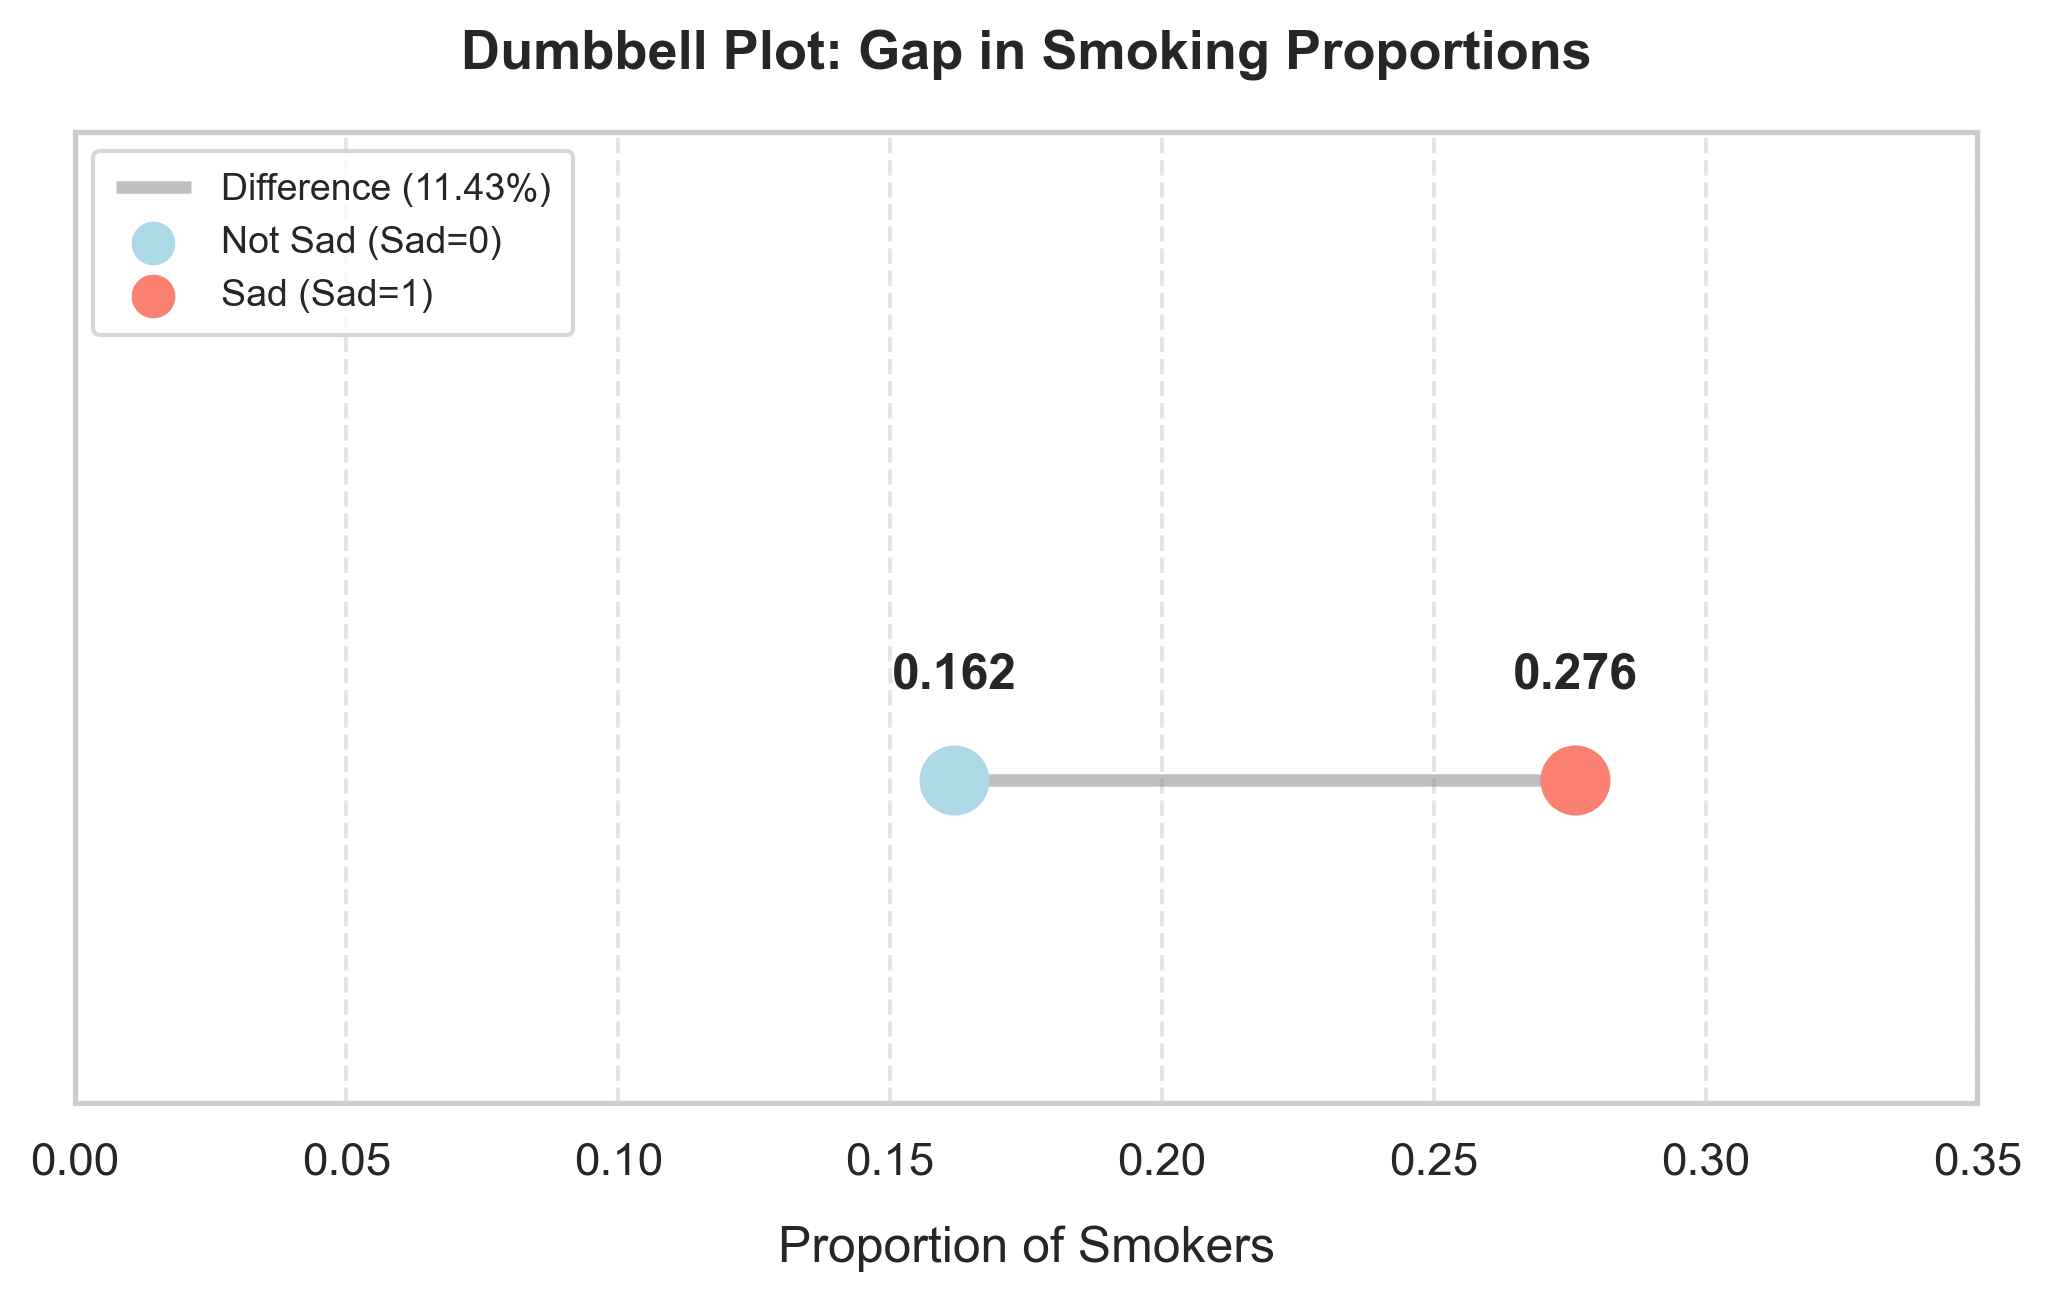

In [7]:
import matplotlib.pyplot as plt

p_0 = 0.161803
p_1 = 0.276077

plt.figure(figsize=(7, 4.5), dpi=300)

plt.hlines(y=1, xmin=p_0, xmax=p_1, color='grey', alpha=0.5, linewidth=3, label='Difference (11.43%)')

plt.scatter(p_0, 1, color='lightblue', s=250, zorder=5, label='Not Sad (Sad=0)')
plt.scatter(p_1, 1, color='salmon', s=250, zorder=5, label='Sad (Sad=1)')

plt.text(p_0, 1.05, f'{p_0:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.text(p_1, 1.05, f'{p_1:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlim(0.00, 0.35)
plt.xticks([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
plt.xlabel('Proportion of Smokers', fontsize=12, labelpad=10)

plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=1)

plt.yticks([])
plt.ylim(0.8, 1.4)

plt.legend(loc='upper left', fontsize=9, markerscale=0.6, frameon=True, borderpad=0.6)
plt.title('Dumbbell Plot: Gap in Smoking Proportions', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/dumbbell_plot_perfect.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation of Dumbbell Plot:**
This gap analysis isolates the exact difference in proportions between the two groups. The grey line connecting the two points represents the difference ($p_1 - p_0$) that will be formally tested.

# 03 Two-Sample Inference

## Two-Proportion Z-Test Setup
* **Method:** Two-proportion z-test
* **Null Hypothesis (H0):** p1 - p2 = 0
* **Alternative Hypothesis (Ha):** p1 - p2 != 0
* **Significance Level (Alpha):** 0.05

In [8]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np
import pandas as pd

count_1 = df_clean[df_clean['Sad_recoded'] == 1]['Smoke_recoded'].sum()
count_0 = df_clean[df_clean['Sad_recoded'] == 0]['Smoke_recoded'].sum()
counts = np.array([count_1, count_0])

nobs_1 = len(df_clean[df_clean['Sad_recoded'] == 1])
nobs_0 = len(df_clean[df_clean['Sad_recoded'] == 0])
nobs = np.array([nobs_1, nobs_0])

z_stat, p_value = proportions_ztest(counts, nobs)
ci_lower, ci_upper = proportion_confint(counts, nobs, alpha=0.05)
diff_estimate = (count_1 / nobs_1) - (count_0 / nobs_0)

results_df = pd.DataFrame({
    'Metric': ['Group 1 (Sad=1) p1', 'Group 0 (Sad=0) p0', 'Estimated Difference (p1-p0)', 'Z-statistic', 'P-value', '95% CI Lower', '95% CI Upper'],
    'Value': [count_1/nobs_1, count_0/nobs_0, diff_estimate, z_stat, p_value, ci_lower[0]-ci_lower[1], ci_upper[0]-ci_upper[1]]
})

results_df.to_csv('../outputs/tables/z_test_results.csv', index=False, encoding='utf-8')

print("--- Two-Sample Z-Test Results ---")
display(results_df)

--- Two-Sample Z-Test Results ---


,Metric,Value
0,Group 1 (Sad=1) p1,2.760768e-01
1,Group 0 (Sad=0) p0,1.618026e-01
2,Estimated Difference (p1-p0),1.142742e-01
3,Z-statistic,1.505364e+01
4,P-value,3.267448e-51
5,95% CI Lower,1.076368e-01
6,95% CI Upper,1.209117e-01


**Interpretation of Test Results:**
The resulting p-value is extremely small. If the p-value is less than the significance level of 0.05, it indicates strong evidence against the null hypothesis.

95% CI for Difference (p1 - p0): (0.0983, 0.1302)


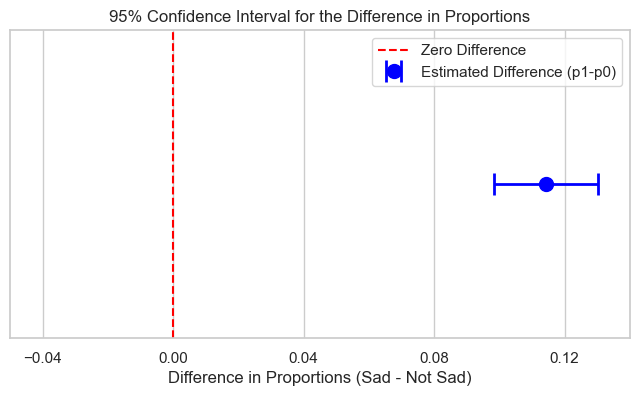

In [9]:
p1_hat = count_1 / nobs_1
p0_hat = count_0 / nobs_0
se_diff = np.sqrt((p1_hat * (1 - p1_hat) / nobs_1) + (p0_hat * (1 - p0_hat) / nobs_0))

ci_diff_lower = diff_estimate - 1.96 * se_diff
ci_diff_upper = diff_estimate + 1.96 * se_diff

print(f"95% CI for Difference (p1 - p0): ({ci_diff_lower:.4f}, {ci_diff_upper:.4f})")

plt.figure(figsize=(8, 4))
plt.axvline(x=0, color='red', linestyle='--', label='Zero Difference')

plt.errorbar(x=diff_estimate, y=0, 
             xerr=[[diff_estimate - ci_diff_lower], [ci_diff_upper - diff_estimate]], 
             fmt='o', color='blue', markersize=10, capsize=8, capthick=2, elinewidth=2, 
             label='Estimated Difference (p1-p0)')

plt.xlim(-0.05, 0.14)
plt.xticks([-0.04, 0.00, 0.04, 0.08, 0.12])

plt.yticks([])
plt.title('95% Confidence Interval for the Difference in Proportions')
plt.xlabel('Difference in Proportions (Sad - Not Sad)')
plt.legend(loc='upper right')

plt.savefig('../outputs/figures/confidence_interval_plot.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation of Confidence Interval Plot:**
The 95% confidence interval for the difference in proportions does not contain zero (the red dashed line). This visually confirms the statistical significance derived from the p-value.

# 04 Final Conclusion

Since the p-value < 0.05 and the confidence interval does not cross zero, we reject the null hypothesis. There is a statistically significant difference in the proportion of current cigarette use between the two groups. Specifically, students who felt sad or hopeless have a significantly higher proportion of current cigarette use than their peers.